# LOAN DEFAULT RISK PREDICTION MACHINE LEARNING MODEL 

### LOGISTIC REGRESSION AND XGBOOST





### DATA COLLECTION

#### Import important libraries

In [1]:
import pandas as pd
import numpy as np
import shap

#### Import data visualisation libraries

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

supress and hide all runtime warning messages

In [3]:
import warnings
warnings.filterwarnings('ignore')

#### Import datasets from the csv file

In [4]:
app=pd.read_csv("Downloads/Loan default risk prediction data/HC_application_train.csv")
prev_app=pd.read_csv("Downloads/Loan default risk prediction data/HC_previous_application.csv")
bureau=pd.read_csv('Downloads/Loan default risk prediction data/HC_bureau.csv')
Test_data=pd.read_csv("Downloads/application_test.csv")

### EXPLORATORY DATA ANALYSIS

In [5]:
app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
prev_app.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [8]:
app.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [9]:
Test_data.describe()

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,48744.000000,48744.000000,4.874400e+04,4.874400e+04,48720.000000,4.874400e+04,48744.000000,48744.000000,48744.000000,48744.000000,...,48744.000000,48744.0,48744.0,48744.0,42695.000000,42695.000000,42695.000000,42695.000000,42695.000000,42695.000000
mean,277796.676350,0.397054,1.784318e+05,5.167404e+05,29426.240209,4.626188e+05,0.021226,-16068.084605,67485.366322,-4967.652716,...,0.001559,0.0,0.0,0.0,0.002108,0.001803,0.002787,0.009299,0.546902,1.983769
std,103169.547296,0.709047,1.015226e+05,3.653970e+05,16016.368315,3.367102e+05,0.014428,4325.900393,144348.507136,3552.612035,...,0.039456,0.0,0.0,0.0,0.046373,0.046132,0.054037,0.110924,0.693305,1.838873
min,100001.000000,0.000000,2.694150e+04,4.500000e+04,2295.000000,4.500000e+04,0.000253,-25195.000000,-17463.000000,-23722.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,188557.750000,0.000000,1.125000e+05,2.606400e+05,17973.000000,2.250000e+05,0.010006,-19637.000000,-2910.000000,-7459.250000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,277549.000000,0.000000,1.575000e+05,4.500000e+05,26199.000000,3.960000e+05,0.018850,-15785.000000,-1293.000000,-4490.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,367555.500000,1.000000,2.250000e+05,6.750000e+05,37390.500000,6.300000e+05,0.028663,-12496.000000,-296.000000,-1901.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000
max,456250.000000,20.000000,4.410000e+06,2.245500e+06,180576.000000,2.245500e+06,0.072508,-7338.000000,365243.000000,0.000000,...,1.000000,0.0,0.0,0.0,2.000000,2.000000,2.000000,6.000000,7.000000,17.000000


### FEATURE ENGENEERING

#### Debt to income ratio

In [10]:
app['DTI_RATIO']=app['AMT_ANNUITY']/app['AMT_INCOME_TOTAL']

In [11]:
Test_data['DTI_RATIO']=Test_data['AMT_ANNUITY']/Test_data['AMT_INCOME_TOTAL']

In [12]:
app["DTI_RATIO"].describe()

count    307499.000000
mean          0.180930
std           0.094574
min           0.000224
25%           0.114782
50%           0.162833
75%           0.229067
max           1.875965
Name: DTI_RATIO, dtype: float64

#### Credit to income ratio

In [13]:
app['CREDIT_TO_INCOME_RATIO']=app['AMT_CREDIT']/app['AMT_INCOME_TOTAL']

In [14]:
Test_data['CREDIT_TO_INCOME_RATIO']=Test_data['AMT_CREDIT']/Test_data['AMT_INCOME_TOTAL']

In [15]:
app['CREDIT_TO_INCOME_RATIO'].describe()

count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
25%           2.018667
50%           3.265067
75%           5.159880
max          84.736842
Name: CREDIT_TO_INCOME_RATIO, dtype: float64

In [16]:
app[app['CREDIT_TO_INCOME_RATIO']==app['CREDIT_TO_INCOME_RATIO'].max()]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DTI_RATIO,CREDIT_TO_INCOME_RATIO
20727,124157,1,Cash loans,F,Y,Y,0,25650.0,2173500.0,48118.5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1.875965,84.736842


#### Age of credit history from the bureau

In [17]:
bureau_agg=bureau.groupby('SK_ID_CURR').agg(BUREAU_DAYS_CREDIT_MIN=('DAYS_CREDIT','min'),
                                           BUREAU_DAYS_CREDIT_MAX=('DAYS_CREDIT','max'),
                                           BUREAU_CREDIT_ACTIVE= ('CREDIT_ACTIVE', lambda x: (x=='Active').sum()),
                                           TOTAL_BUREAU_CREDIT_DAY_OVERDUE=('CREDIT_DAY_OVERDUE', lambda x: (x>0).sum()))

In [18]:
app=app.merge(bureau_agg,on='SK_ID_CURR',how='left')

In [19]:
Test_data=Test_data.merge(bureau_agg,on='SK_ID_CURR',how='left')

#### Number of the previous loans

In [20]:
prev_app['NAME_CONTRACT_STATUS'].value_counts()

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

In [21]:
prev_app_agg=prev_app.groupby('SK_ID_CURR').agg(NUMBER_OF_PAST_APPS=('SK_ID_PREV',lambda x: (x).count()),
                                                PREVIOUS_REFUSED_RATIO=('NAME_CONTRACT_STATUS', lambda x:(x=='Refused').mean()))

In [22]:
prev_app_agg.describe()

,NUMBER_OF_PAST_APPS,PREVIOUS_REFUSED_RATIO
count,338857.000000,338857.00000
mean,4.928964,0.11142
std,4.220716,0.18373
min,1.000000,0.00000
25%,2.000000,0.00000
50%,4.000000,0.00000
75%,7.000000,0.20000
max,77.000000,1.00000


In [23]:
app=app.merge(prev_app_agg,on='SK_ID_CURR',how='left')

In [24]:
Test_data=Test_data.merge(prev_app_agg,on='SK_ID_CURR',how='left')

In [25]:
app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DTI_RATIO,CREDIT_TO_INCOME_RATIO,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_CREDIT_ACTIVE,TOTAL_BUREAU_CREDIT_DAY_OVERDUE,NUMBER_OF_PAST_APPS,PREVIOUS_REFUSED_RATIO
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,1.0,0.121978,2.007889,-1437.0,-103.0,2.0,0.0,1.0,0.000000
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.132217,4.790750,-2586.0,-606.0,1.0,0.0,3.0,0.000000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.100000,2.000000,-1326.0,-408.0,0.0,0.0,1.0,0.000000
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,0.219900,2.316167,NaN,NaN,NaN,NaN,9.0,0.111111
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.179963,4.222222,-1149.0,-1149.0,0.0,0.0,6.0,0.000000


In [26]:
Test_data.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DTI_RATIO,CREDIT_TO_INCOME_RATIO,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_CREDIT_ACTIVE,TOTAL_BUREAU_CREDIT_DAY_OVERDUE,NUMBER_OF_PAST_APPS,PREVIOUS_REFUSED_RATIO
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0.0,0.0,0.152300,4.213333,-1572.0,-49.0,3.0,0.0,1.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0.0,3.0,0.175455,2.250182,-373.0,-62.0,2.0,0.0,2.0,0.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,1.0,4.0,0.344578,3.275378,-2070.0,-1210.0,0.0,0.0,4.0,0.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0.0,3.0,0.155614,5.000000,-2105.0,-269.0,5.0,0.0,5.0,0.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,NaN,NaN,0.178150,3.475000,NaN,NaN,NaN,NaN,2.0,0.0


#### Employment period

In [27]:
app[app['DAYS_EMPLOYED']>=0]['DAYS_EMPLOYED'].value_counts()

DAYS_EMPLOYED
365243    55374
0             2
Name: count, dtype: int64

In [28]:
Test_data[Test_data['DAYS_EMPLOYED']>=0]['DAYS_EMPLOYED'].value_counts()

DAYS_EMPLOYED
365243    9274
Name: count, dtype: int64

##### There are days recorded as 365243 which is an anomaly and it should be handled

In [29]:
app['DAYS_EMPLOYED']=app['DAYS_EMPLOYED'].replace({365243: np.nan})

In [30]:
Test_data['DAYS_EMPLOYED']=Test_data['DAYS_EMPLOYED'].replace({365243: np.nan})

In [31]:
app['YEARS_EMPLOYED']=abs(app['DAYS_EMPLOYED'])/365.25

In [32]:
Test_data['YEARS_EMPLOYED']=abs(Test_data['DAYS_EMPLOYED'])/365.25

In [33]:
app['YEARS_EMPLOYED'].describe()

count    252137.000000
mean          6.527500
std           6.402081
min           0.000000
25%           2.099932
50%           4.511978
75%           8.692676
max          49.040383
Name: YEARS_EMPLOYED, dtype: float64

In [34]:
Test_data['YEARS_EMPLOYED'].describe()

count    39470.000000
mean         6.780942
std          6.318861
min          0.002738
25%          2.357290
50%          4.832307
75%          9.113621
max         47.811088
Name: YEARS_EMPLOYED, dtype: float64

#### Applicant's age

In [35]:
app['AGE']=abs(app['DAYS_BIRTH'])/365.25

In [36]:
Test_data['AGE']=abs(Test_data['DAYS_BIRTH'])/365.25

In [37]:
app['AGE'].describe()

count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
25%          33.984942
50%          43.121150
75%          53.886379
max          69.073238
Name: AGE, dtype: float64

In [38]:
Test_data['AGE'].describe()

count    48744.000000
mean        43.992018
std         11.843670
min         20.090349
25%         34.212183
50%         43.216975
75%         53.763176
max         68.980151
Name: AGE, dtype: float64

#### EXTERNAL SOURCES SCORES

In [39]:
app[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].describe()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,134133.000000,3.068510e+05,246546.000000
mean,0.502130,5.143927e-01,0.510853
std,0.211062,1.910602e-01,0.194844
min,0.014568,8.173617e-08,0.000527
25%,0.334007,3.924574e-01,0.370650
50%,0.505998,5.659614e-01,0.535276
75%,0.675053,6.636171e-01,0.669057
max,0.962693,8.549997e-01,0.896010


In [40]:
app['EXT_SOURCE_MEAN']=app[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)

In [41]:
Test_data['EXT_SOURCE_MEAN']=Test_data[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)

### DATA CLEANING AND TRANSFORMATION

<Axes: >

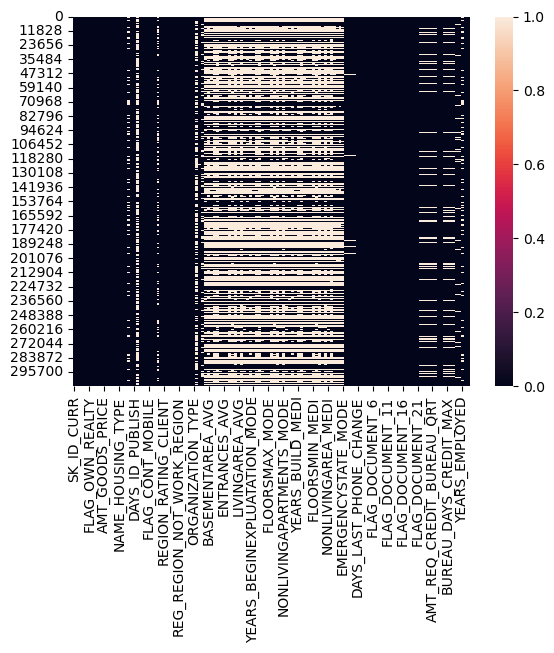

In [42]:
sns.heatmap(app.isnull())

##### Missing values flag

Create two new columns "EXT_SOURCE_1_MISSING AND AMT_ANNUITY_MISSING" and fill values 1 for the missing and 0 for the ones with values

In [43]:
for col in ['EXT_SOURCE_1','AMT_ANNUITY']:
   app[f'{col}_MISSING']=app[col].isnull().astype(int)

In [44]:
for col in ['EXT_SOURCE_1','AMT_ANNUITY']:
   Test_data[f'{col}_MISSING']=Test_data[col].isnull().astype(int)

#### Encoding Applicant's gender

In [45]:
app['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [46]:
app['CODE_GENDER']=app['CODE_GENDER'].map({'F':0,'M':1,'XNA':2})

In [47]:
app['CODE_GENDER'].value_counts()

CODE_GENDER
0    202448
1    105059
2         4
Name: count, dtype: int64

#### Fill the remaining NaN

In [48]:
app=app.fillna(app.median(numeric_only=True))

In [49]:
Test_data=Test_data.fillna(app.median(numeric_only=True))

In [50]:
app[app['SK_ID_CURR']==app['SK_ID_CURR'].isnull()]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,BUREAU_DAYS_CREDIT_MAX,BUREAU_CREDIT_ACTIVE,TOTAL_BUREAU_CREDIT_DAY_OVERDUE,NUMBER_OF_PAST_APPS,PREVIOUS_REFUSED_RATIO,YEARS_EMPLOYED,AGE,EXT_SOURCE_MEAN,EXT_SOURCE_1_MISSING,AMT_ANNUITY_MISSING


In [51]:
Test_data[Test_data['SK_ID_CURR']==Test_data['SK_ID_CURR'].isnull()]

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,BUREAU_DAYS_CREDIT_MAX,BUREAU_CREDIT_ACTIVE,TOTAL_BUREAU_CREDIT_DAY_OVERDUE,NUMBER_OF_PAST_APPS,PREVIOUS_REFUSED_RATIO,YEARS_EMPLOYED,AGE,EXT_SOURCE_MEAN,EXT_SOURCE_1_MISSING,AMT_ANNUITY_MISSING


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score,classification_report,confusion_matrix

### Feature selection 

In [53]:
features=['DTI_RATIO','CREDIT_TO_INCOME_RATIO','BUREAU_DAYS_CREDIT_MIN','BUREAU_DAYS_CREDIT_MAX',
          'BUREAU_CREDIT_ACTIVE','TOTAL_BUREAU_CREDIT_DAY_OVERDUE','NUMBER_OF_PAST_APPS',
          'PREVIOUS_REFUSED_RATIO','YEARS_EMPLOYED','EXT_SOURCE_MEAN','AGE','CNT_CHILDREN']
#'CODE_GENDER'

In [54]:
X=app[features]
y=app['TARGET']

<Axes: >

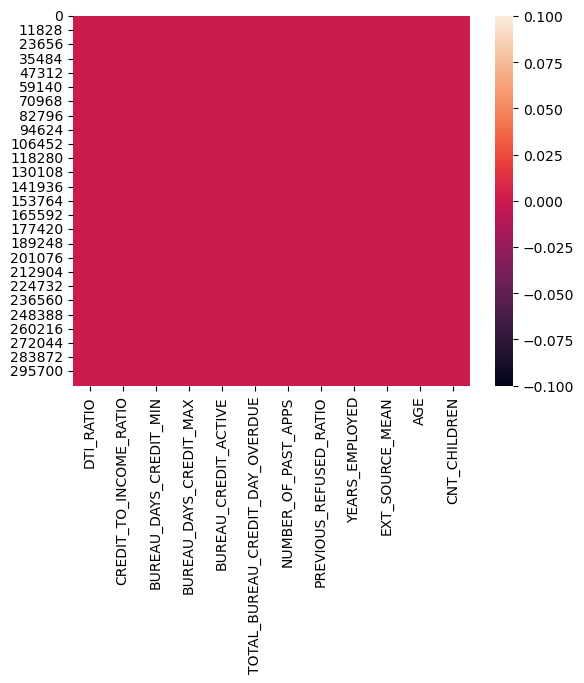

In [55]:
sns.heatmap(X.isnull())

#### Splitting data into train and validation data

In [56]:
X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=0.30, random_state=1)

### Model training

#### Logistic Regression

In [57]:
LogReg=LogisticRegression(max_iter=3000,class_weight='balanced')
LogReg.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [58]:
y_pred_prob=LogReg.predict_proba(X_validation)[:,1]

In [59]:
y_pred_prob

array([0.32461393, 0.4016497 , 0.26193652, ..., 0.30875389, 0.32804964,
       0.38121663], shape=(92254,))

#### Roc_Auc and average_Precision_score

In [60]:
print("Roc_Auc:",roc_auc_score(y_validation,y_pred_prob))
print("average_precision_score:",average_precision_score(y_validation,y_pred_prob))

Roc_Auc: 0.7296222137750653
average_precision_score: 0.21129893886556533


#### Threshold selection using cost minimising function

In [61]:
from sklearn.metrics import precision_recall_curve

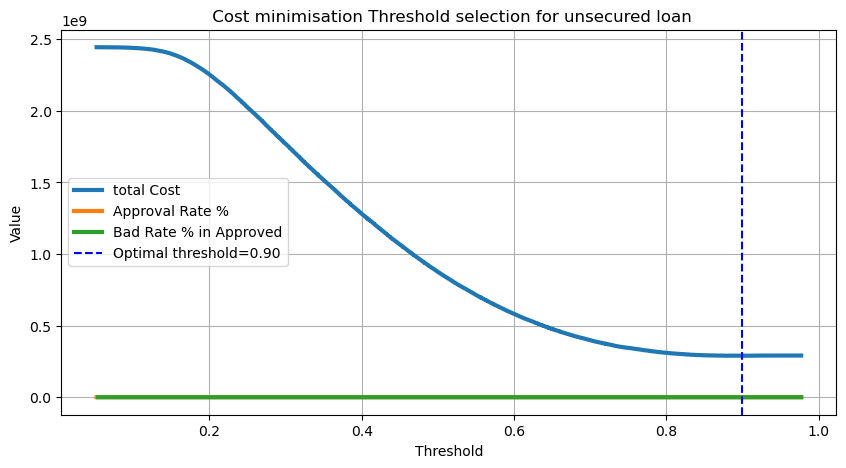

Optimal threshold: 0.90
Approval rate at best threshold : 99.81%
Bad rate at best threshold : 8.01%


In [62]:
precision, recall, thresholds= precision_recall_curve(y_validation,y_pred_prob)

average_loan = 50000 # Average of Absa : R30 000-R65 000, Capitec :R25 000-R60 000, FNB : R35 000-R75 000, Nedbank :R35 000-R70 000 and Standard bank : R28 000-R60 000 average personal loan
LGD= 0.78 # Loss given default is 78%, Average of Absa : 78%,FNB : 75%, Standard bank : 80% and Capitec :82% average personal loan only 22% is recorvered 
interest_rate = 0.21 # Bank average annual interest rate from Absa : 21.4%, FNB : 22.6%, Nedbank:18.5%, Standard bank :22.4% and Capitec :20% average personal loan
term_years = 4 # Bank loan average term is 4 years
initiation_fee=1207.50 # South African banks NCA initiation fee is R1207.50 except for FNB which is free
service_fee=69 # South African banks NCA service fee is R69.00 except for FNB which is free

Benefit_TP = average_loan*LGD #Cost saved in rejecting a bad customer ~R28 837.17
Cost_FN = average_loan*LGD #Cost lost in approving a bad customer ~R39 000.00
Cost_FP = ((average_loan/((1-(1+(interest_rate/12))**(-term_years*12))/(interest_rate/12)))*(term_years*12)
+initiation_fee+(service_fee*term_years*12)-average_loan) #Cost lost in rejecting a good customer ~R28 837.17

Costs=[]
Approval_rate=[]
Bad_rate=[]

for threshold in thresholds:
    preds=(y_pred_prob>=threshold).astype(int)
    FP=((y_validation==0)&(preds==1)).sum()
    FN=((y_validation==1)&(preds==0)).sum()
    TP=((y_validation==1)&(preds==1)).sum()
    TN=((y_validation==0)&(preds==0)).sum()
    Costs.append(FP*Cost_FP+FN*Cost_FN)
    Approval_rate.append((preds==0).mean())
    Bad_rate.append(FN/(TN+FN))

Best_threshold=thresholds[np.argmin(Costs)]
plt.figure(figsize=(10,5))
plt.plot(thresholds,Costs,label="total Cost",linewidth=3)
plt.plot(thresholds, np.array(Approval_rate)*100,label='Approval Rate %',linewidth=3)
plt.plot(thresholds, np.array(Bad_rate)*100,label="Bad Rate % in Approved", linewidth=3)

Best_threshold=thresholds[np.argmin(Costs)]
plt.axvline(Best_threshold,color="blue",ls="--",label=f"Optimal threshold={Best_threshold:,.2f}")
plt.xlabel("Threshold")
plt.ylabel("Value")
plt.title(" Cost minimisation Threshold selection for unsecured loan")
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal threshold: {Best_threshold:.2f}")
print(f"Approval rate at best threshold : {np.mean((y_pred_prob<Best_threshold))*100:.2f}%")
print(f"Bad rate at best threshold : {np.mean(y_validation[y_pred_prob<Best_threshold])*100:.2f}%")

In [63]:
Cost_FN

39000.0

In [64]:
Cost_FP

28837.167916617327

In [65]:
print(f"The cost of default is {Cost_FN/Cost_FP :.2f} times the cost of rejecting a good customer")

The cost of default is 1.35 times the cost of rejecting a good customer


#### Calibrate the probabilities for Logistic Regression Model

In [66]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

calbrated = CalibratedClassifierCV(LogReg,cv=5,method="sigmoid")
calbrated.fit(X_train,y_train)
y_pred_prob_cal=calbrated.predict_proba(X_validation)[:,1]
print("Brier score before:", brier_score_loss(y_validation,y_pred_prob))
print("Brier score after:", brier_score_loss(y_validation,y_pred_prob_cal))

Brier score before: 0.2093548177264318
Brier score after: 0.06954469690082794


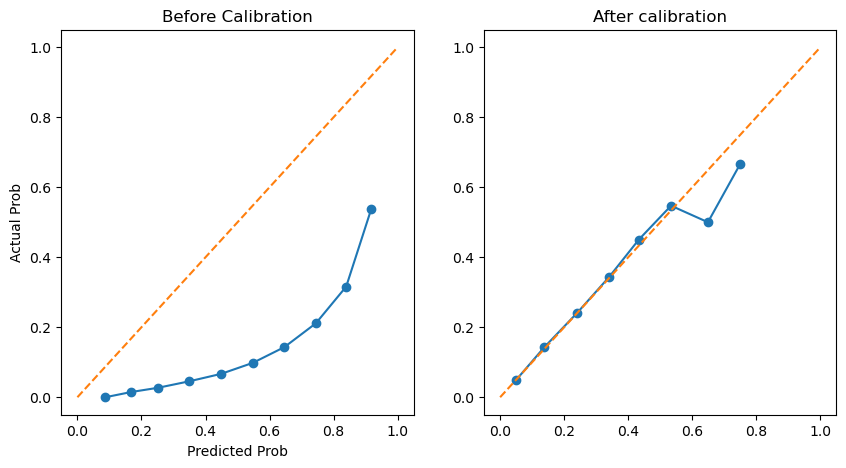

In [67]:
from sklearn.calibration import calibration_curve
precision, recall, thresholds= precision_recall_curve(y_validation,y_pred_prob_cal)

average_loan = 50000 # Average of Absa : R30 000-R65 000, Capitec :R25 000-R60 000, FNB : R35 000-R75 000, Nedbank :R35 000-R70 000 and Standard bank : R28 000-R60 000 average personal loan
LGD= 0.78 # Loss given default is 78%, Average of Absa : 78%,FNB : 75%, Standard bank : 80% and Capitec :82% average personal loan only 22% is recorvered 
interest_rate = 0.21 # Bank average annual interest rate from Absa : 21.4%, FNB : 22.6%, Nedbank:18.5%, Standard bank :22.4% and Capitec :20% average personal loan
term_years = 4 # Bank loan average term is 4 years
initiation_fee=1207.50 # South African banks NCA initiation fee is R1207.50 except for FNB which is free
service_fee=69 # South African banks NCA service fee is R69.00 except for FNB which is free

Benefit_TP = average_loan*LGD #Cost saved in rejecting a bad customer ~R28 837.17
Cost_FN = average_loan*LGD #Cost lost in approving a bad customer ~R39 000.00
Cost_FP = ((average_loan/((1-(1+(interest_rate/12))**(-term_years*12))/(interest_rate/12)))*(term_years*12)
+initiation_fee+(service_fee*term_years*12)-average_loan) #Cost lost in rejecting a good customer ~R28 837.17

Costs=[]
Approval_rate=[]
Bad_rate=[]

for threshold in thresholds:
    preds=(y_pred_prob_cal>=threshold).astype(int)
    FP=((y_validation==0)&(preds==1)).sum()
    FN=((y_validation==1)&(preds==0)).sum()
    TP=((y_validation==1)&(preds==1)).sum()
    TN=((y_validation==0)&(preds==0)).sum()
    Costs.append(FP*Cost_FP+FN*Cost_FN)
    Approval_rate.append((preds==0).mean())
    Bad_rate.append(FN/(TN+FN))
    
Best_threshold=thresholds[np.argmin(Costs)]
    

fig, ax = plt.subplots(1,2,figsize=(10,5))
prob_true,prob_pred=calibration_curve(y_validation,y_pred_prob,n_bins=10)
ax[0].plot(prob_pred,prob_true,marker="o")
ax[0].plot([0,1],[0,1],ls="--")
ax[0].set_title("Before Calibration")
ax[0].set_xlabel("Predicted Prob")
ax[0].set_ylabel("Actual Prob")

prob_true_cal,prob_pred_cal=calibration_curve(y_validation,y_pred_prob_cal,n_bins=10)
ax[1].plot(prob_pred_cal,prob_true_cal,marker="o")
ax[1].plot([0,1],[0,1],ls="--")
ax[1].set_title("After calibration")
plt.show()

#### Threshold after calibration method

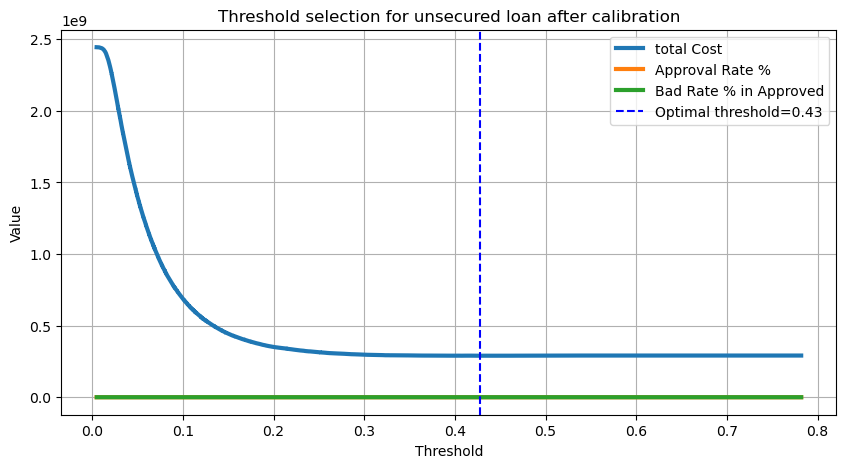

Optimal threshold: 0.43
Approval rate at best threshold : 99.78%
Bad rate at best threshold : 8.00%


In [68]:
plt.figure(figsize=(10,5))
plt.plot(thresholds,Costs,label="total Cost",linewidth=3)
plt.plot(thresholds, np.array(Approval_rate)*100,label='Approval Rate %',linewidth=3)
plt.plot(thresholds, np.array(Bad_rate)*100,label="Bad Rate % in Approved", linewidth=3)

best_threshold=thresholds[np.argmin(Costs)]
plt.axvline(best_threshold,color="blue",ls="--",label=f"Optimal threshold={best_threshold:,.2f}")
plt.xlabel("Threshold")
plt.ylabel("Value")
plt.title("Threshold selection for unsecured loan after calibration")
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Approval rate at best threshold : {np.mean((y_pred_prob_cal<best_threshold))*100:.2f}%")
print(f"Bad rate at best threshold : {np.mean(y_validation[y_pred_prob_cal<best_threshold])*100:.2f}%")

#### Results with a Threshold calculated from a cost_based method

In [69]:
treshold= 0.43

In [70]:
LogReg_pred_labels=(y_pred_prob>treshold).astype(int)

In [71]:
LogReg_pred_labels

array([0, 0, 0, ..., 0, 0, 0], shape=(92254,))

In [72]:
print(classification_report(y_validation,LogReg_pred_labels))
print(confusion_matrix(y_validation,LogReg_pred_labels))

              precision    recall  f1-score   support

           0       0.96      0.56      0.71     84787
           1       0.13      0.76      0.22      7467

    accuracy                           0.57     92254
   macro avg       0.55      0.66      0.47     92254
weighted avg       0.90      0.57      0.67     92254

[[47283 37504]
 [ 1782  5685]]


In [73]:
LogReg_tp=((y_validation==1) & (LogReg_pred_labels==1)).sum()
LogReg_fp=((y_validation==0) & (LogReg_pred_labels==1)).sum()
LogReg_fn=((y_validation==1) & (LogReg_pred_labels==0)).sum()
LogReg_tn=((y_validation==0) & (LogReg_pred_labels==0)).sum()

In [74]:
print('LogReg true positives:',LogReg_tp)
print('LogReg false positives:',LogReg_fp)
print('LogReg false negatives:',LogReg_fn)
print('LogReg true negative:',LogReg_tn)

LogReg true positives: 5685
LogReg false positives: 37504
LogReg false negatives: 1782
LogReg true negative: 47283


### Business Impact from Logistic Regression model

In [75]:
average_loan=50000
loss_given_difault = 0.75
review_cost = 50

In [76]:
gross_loss_prevented=LogReg_tp*average_loan*loss_given_difault 
ops_cost=(LogReg_tp+LogReg_fp)*review_cost
Net_benefit=gross_loss_prevented-ops_cost

In [77]:
print(f"Model flags:{(LogReg_tp+LogReg_fp)} aps")
print(f"Caught defaults: {LogReg_tp} | Missed defaults: {LogReg_fn}")
print(f"Amount lost on rejecting good borrower:R {LogReg_fp*average_loan*(1-loss_given_difault):,.2f}|Amount lost through Missed defaults:R {LogReg_fn*average_loan*loss_given_difault:,.2f}")
print(f"Expected Loss: R{(LogReg_fp*average_loan*(1-loss_given_difault)+LogReg_fn*average_loan*loss_given_difault):,.2f}")
print(f"Gross_loss_prevented: R{gross_loss_prevented:,.2f}")
print(f"Operations cost: R{ops_cost:,.2f}")
print(f"Net benefit : R{Net_benefit:,.2f}")
print(f"Recall:{LogReg_tp/(LogReg_tp+LogReg_fn):,.2f} | Precision:{LogReg_tp/(LogReg_tp+LogReg_fp):,.2f}")

Model flags:43189 aps
Caught defaults: 5685 | Missed defaults: 1782
Amount lost on rejecting good borrower:R 468,800,000.00|Amount lost through Missed defaults:R 66,825,000.00
Expected Loss: R535,625,000.00
Gross_loss_prevented: R213,187,500.00
Operations cost: R2,159,450.00
Net benefit : R211,028,050.00
Recall:0.76 | Precision:0.13


#### Better performance

In [78]:
from xgboost import XGBClassifier 
from sklearn.calibration  import CalibratedClassifierCV

In [79]:
xgb=XGBClassifier(n_estimators=300,
                  max_depth=4, 
                  learning_rate=0.02,
                  subsample=0.8,
                  colsample_bytree=0.8,
                  scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                  eval_metric="auc",random_state=1)

In [80]:
xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [81]:
y_xgb_pred_prob=xgb.predict_proba(X_validation)[:,1]

#### Roc_Auc and average_Precision_score

In [82]:
print("Roc_Auc:",roc_auc_score(y_validation,y_xgb_pred_prob))
print("average_precision_score:",average_precision_score(y_validation,y_xgb_pred_prob))

Roc_Auc: 0.7378233215892853
average_precision_score: 0.22269599955403807


#### XGBOOST has performed well compared to Logistic regression model. hence choosing xgb is the best decision

#### Calibrated probabilities for xgboost

In [83]:
calibrated_xgb=CalibratedClassifierCV(xgb,method="sigmoid",cv=5)
calibrated_xgb.fit(X_train,y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [84]:
y_xgb_prob_cal=calibrated_xgb.predict_proba(X_validation)[:,1]

In [85]:
print("Brier score before:", brier_score_loss(y_validation,y_xgb_pred_prob))
print("Brier score after:", brier_score_loss(y_validation,y_xgb_prob_cal))

Brier score before: 0.20513135173082422
Brier score after: 0.06915451982492561


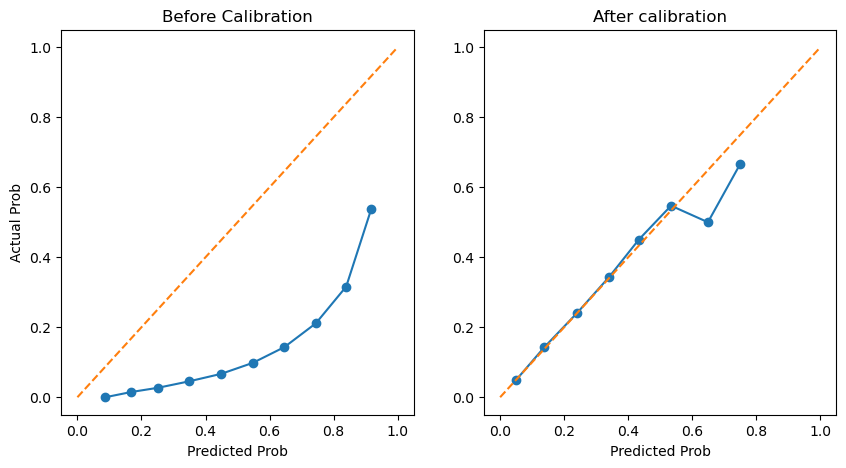

In [86]:
from sklearn.calibration import calibration_curve
precision, recall, thresholds= precision_recall_curve(y_validation,y_xgb_prob_cal)

average_loan = 50000 # Average of Absa : R30 000-R65 000, Capitec :R25 000-R60 000, FNB : R35 000-R75 000, Nedbank :R35 000-R70 000 and Standard bank : R28 000-R60 000 average personal loan
LGD= 0.78 # Loss given default is 78%, Average of Absa : 78%,FNB : 75%, Standard bank : 80% and Capitec :82% average personal loan only 22% is recorvered 
interest_rate = 0.21 # Bank average annual interest rate from Absa : 21.4%, FNB : 22.6%, Nedbank:18.5%, Standard bank :22.4% and Capitec :20% average personal loan
term_years = 4 # Bank loan average term is 4 years
initiation_fee=1207.50 # South African banks NCA initiation fee is R1207.50 except for FNB which is free
service_fee=69 # South African banks NCA service fee is R69.00 except for FNB which is free

Benefit_TP = average_loan*LGD #Cost saved in rejecting a bad customer ~R28 837.17
Cost_FN = average_loan*LGD #Cost lost in approving a bad customer ~R39 000.00
Cost_FP = ((average_loan/((1-(1+(interest_rate/12))**(-term_years*12))/(interest_rate/12)))*(term_years*12)
+initiation_fee+(service_fee*term_years*12)-average_loan) #Cost lost in rejecting a good customer ~R28 837.17

Costs=[]
Approval_rate=[]
Bad_rate=[]
for threshold in thresholds:
    preds=(y_xgb_prob_cal>=threshold).astype(int)
    FP=((y_validation==0)&(preds==1)).sum()
    FN=((y_validation==1)&(preds==0)).sum()
    TP=((y_validation==1)&(preds==1)).sum()
    TN=((y_validation==0)&(preds==0)).sum()
    Costs.append(FP*Cost_FP+FN*Cost_FN)
    Approval_rate.append((preds==0).mean())
    Bad_rate.append(FN/(TN+FN+1e-9))
    
Best_threshold=thresholds[np.argmin(Costs)]
best_threshold=thresholds[np.argmin(Costs)]
    

fig, ax = plt.subplots(1,2,figsize=(10,5))
prob_true,prob_pred=calibration_curve(y_validation,y_pred_prob,n_bins=10)
ax[0].plot(prob_pred,prob_true,marker="o")
ax[0].plot([0,1],[0,1],ls="--")
ax[0].set_title("Before Calibration")
ax[0].set_xlabel("Predicted Prob")
ax[0].set_ylabel("Actual Prob")

prob_true_cal,prob_pred_cal=calibration_curve(y_validation,y_pred_prob_cal,n_bins=10)
ax[1].plot(prob_pred_cal,prob_true_cal,marker="o")
ax[1].plot([0,1],[0,1],ls="--")
ax[1].set_title("After calibration")
ax[1].set_xlabel("Predicted Prob")
plt.show()

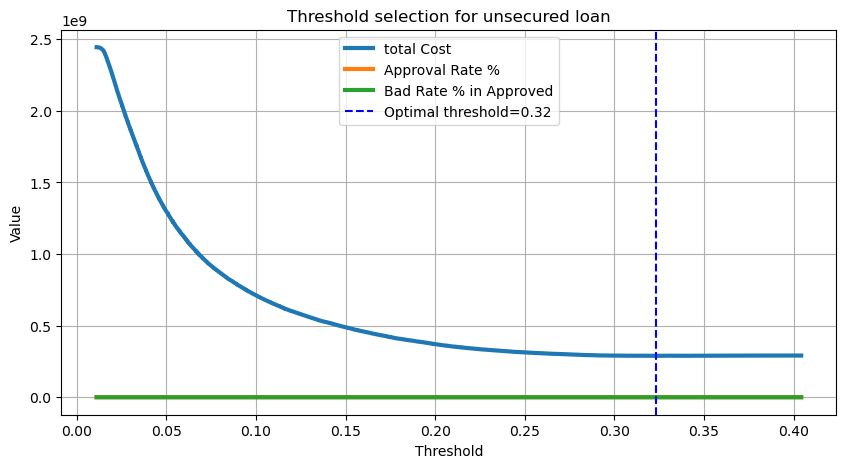

Optimal threshold: 0.32
Approval rate at best threshold : 98.71%
Bad rate at best threshold : 7.68%


In [87]:
plt.figure(figsize=(10,5))
plt.plot(thresholds,Costs,label="total Cost",linewidth=3)
plt.plot(thresholds, np.array(Approval_rate)*100,label='Approval Rate %',linewidth=3)
plt.plot(thresholds, np.array(Bad_rate)*100,label="Bad Rate % in Approved", linewidth=3)

best_threshold=thresholds[np.argmin(Costs)]
plt.axvline(best_threshold,color="blue",ls="--",label=f"Optimal threshold={best_threshold:,.2f}")
plt.xlabel("Threshold")
plt.ylabel("Value")
plt.title("Threshold selection for unsecured loan")
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Approval rate at best threshold : {np.mean((y_pred_prob_cal<best_threshold))*100:.2f}%")
print(f"Bad rate at best threshold : {np.mean(y_validation[y_pred_prob_cal<best_threshold])*100:.2f}%")

In [88]:
for name,model in [('XGBOOST',xgb)]:
    xgb_pred=model.predict_proba(X_validation)[:,1]
print(f"{name} ROC_AUC : {roc_auc_score(y_validation,xgb_pred):,.2f}")
print(f"{name} PR_AUC:{average_precision_score(y_validation,xgb_pred):,.2f}")

XGBOOST ROC_AUC : 0.74
XGBOOST PR_AUC:0.22


#### Threshold selection using profit maximisation function

Best threshold: 0.32, Max profit: R1,985,686.79


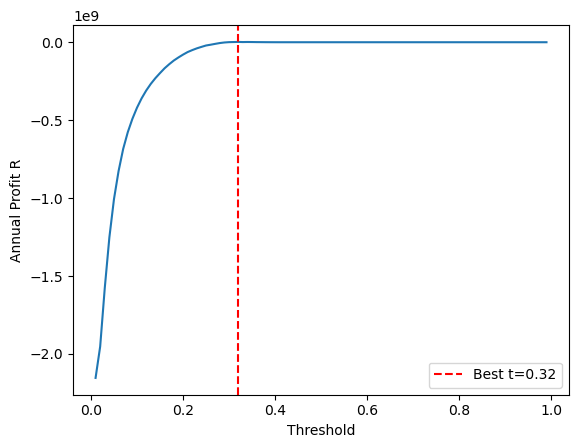

In [89]:
average_loan = 50000 # Average of Absa : R30 000-R65 000, Capitec :R25 000-R60 000, FNB : R35 000-R75 000, Nedbank :R35 000-R70 000 and Standard bank : R28 000-R60 000 average personal loan
LGD= 0.78 # Loss given default is 78%, Average of Absa : 78%,FNB : 75%, Standard bank : 80% and Capitec :82% average personal loan only 22% is recorvered 
interest_rate = 0.21 # Bank average annual interest rate from Absa : 21.4%, FNB : 22.6%, Nedbank:18.5%, Standard bank :22.4% and Capitec :20% average personal loan
term_years = 4 # Bank loan average term is 4 years
initiation_fee=1207.50 # South African banks NCA initiation fee is R1207.50 except for FNB which is free
service_fee=69 # South African banks NCA service fee is R69.00 except for FNB which is free

Benefit_TP = average_loan*LGD #Cost saved in rejecting a bad customer ~R28 837.17
Cost_FN = average_loan*LGD #Cost lost in approving a bad customer ~R39 000.00
Cost_FP = ((average_loan/((1-(1+(interest_rate/12))**(-term_years*12))/(interest_rate/12)))*(term_years*12)
+initiation_fee+(service_fee*term_years*12)-average_loan) #Cost lost in rejecting a good customer ~R28 837.17


thresholds = np.arange(0.01, 1.0, 0.01)
profits = []

for t in thresholds:
    y_pred = (y_xgb_prob_cal>= t).astype(int)
    TN, FP, FN, TP = confusion_matrix(y_validation, y_pred).ravel()
    profit = TP*Cost_FN -FP*Cost_FP  # savings from TP - cost of FP
    profits.append(profit)

best_t = thresholds[np.argmax(profits)]
print(f"Best threshold: {best_t:.2f}, Max profit: R{max(profits):,.2f}")

plt.plot(thresholds, profits)
plt.axvline(best_t, color='red', linestyle='--', label=f'Best t={best_t:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Annual Profit R'); plt.legend()
plt.show()

##### XGB predicted labels with a threshold= 0.32

In [90]:
treshold=0.32 #Average threshold of the cost minimisation threshold of 0.32 and profit miximisation threshold of 0 .32

In [91]:
xgb_pred_labels=(xgb_pred>treshold).astype(int)

In [92]:
print(classification_report(y_validation,xgb_pred_labels))
print(confusion_matrix(y_validation,xgb_pred_labels))

              precision    recall  f1-score   support

           0       0.97      0.33      0.50     84787
           1       0.11      0.90      0.19      7467

    accuracy                           0.38     92254
   macro avg       0.54      0.62      0.34     92254
weighted avg       0.90      0.38      0.47     92254

[[28322 56465]
 [  744  6723]]


In [93]:
xgb_tp=((y_validation==1)& (xgb_pred_labels==1)).sum()
xgb_fp=((y_validation==0)& (xgb_pred_labels==1)).sum()
xgb_fn=((y_validation==1)& (xgb_pred_labels==0)).sum()
xgb_tn=((y_validation==0)& (xgb_pred_labels==0)).sum()

In [94]:
print('xgb true positives:',xgb_tp)
print('xgb false positives:',xgb_fp)
print('xgb false negatives:',xgb_fn)
print('xgb true negative:',xgb_tn)

xgb true positives: 6723
xgb false positives: 56465
xgb false negatives: 744
xgb true negative: 28322


### Business Impact from xgboost

In [95]:
gross_loss_prevented=xgb_tp*average_loan*loss_given_difault 
ops_cost=(xgb_tp+xgb_fp)*review_cost
xgb_Net_benefit=gross_loss_prevented-ops_cost

In [96]:
print(f"Model flags:{(xgb_tp+xgb_fp)} aps")
print(f"Caught defaults: {xgb_tp} | Missed defaults: {xgb_fn}")
print(f"Amount lost on rejecting good borrower:R {xgb_fp*average_loan*(1-loss_given_difault):,.2f}|Amount lost through Missed defaults:R {xgb_fn*average_loan*loss_given_difault:,.2f}")
print(f"Expected Loss: R{(xgb_fp*average_loan*(1-loss_given_difault)+xgb_fn*average_loan*loss_given_difault):,.2f}")
print(f"Gross_loss_prevented: R{gross_loss_prevented:,.2f}")
print(f"Operations cost: R{ops_cost:,.2f}")
print(f"xgb_Net benefit : R{xgb_Net_benefit:,.2f}")
print(f"Recall:{xgb_tp/(xgb_tp+xgb_fn):,.2f} | Precision:{xgb_tp/(xgb_tp+xgb_fp):,.2f}")

Model flags:63188 aps
Caught defaults: 6723 | Missed defaults: 744
Amount lost on rejecting good borrower:R 705,812,500.00|Amount lost through Missed defaults:R 27,900,000.00
Expected Loss: R733,712,500.00
Gross_loss_prevented: R252,112,500.00
Operations cost: R3,159,400.00
xgb_Net benefit : R248,953,100.00
Recall:0.90 | Precision:0.11


#### SHAP plot for explainability

100%|===================| 998/1000 [00:20<00:00]        

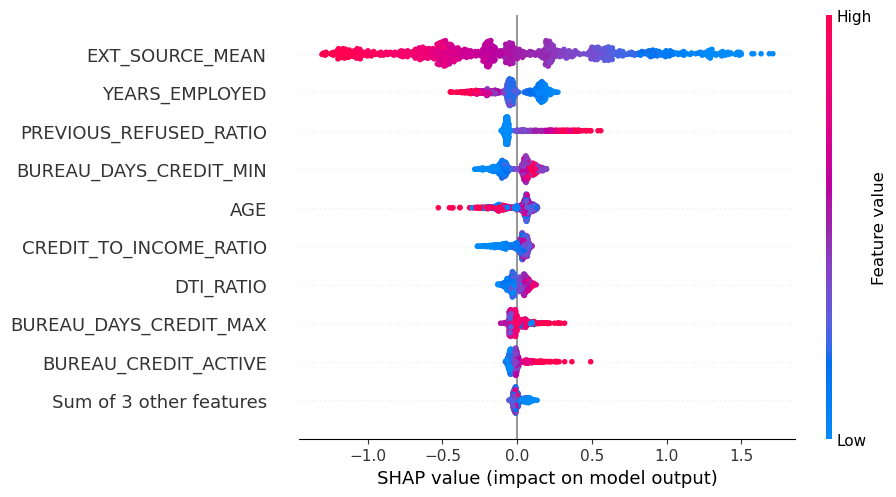

In [97]:
explainer=shap.Explainer(xgb,X_train)
shap_values=explainer(X_validation.iloc[:1000])
shap.plots.beeswarm(shap_values)

#### SHAP waterfall plot for 1 loan applicant 

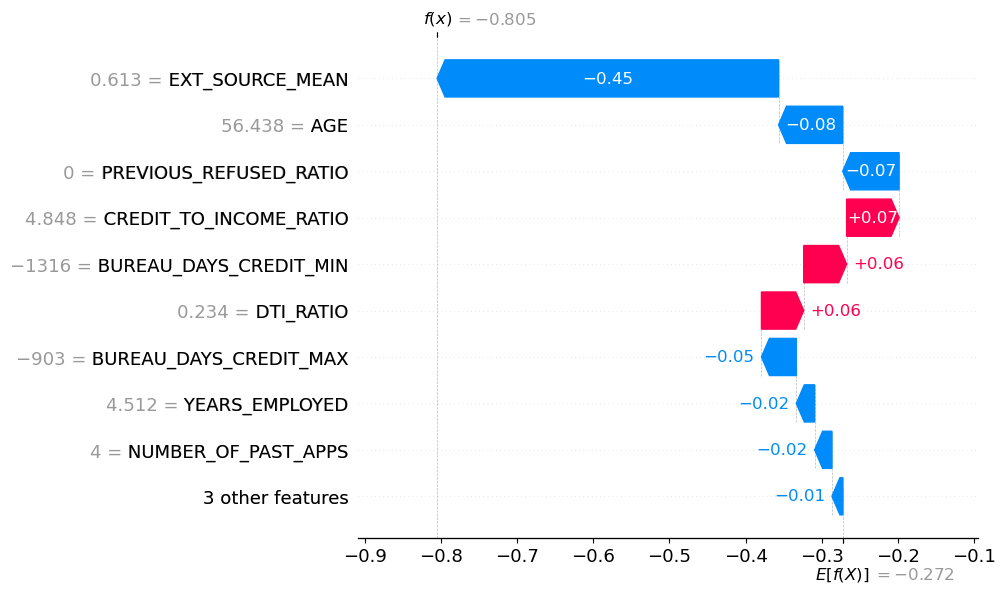

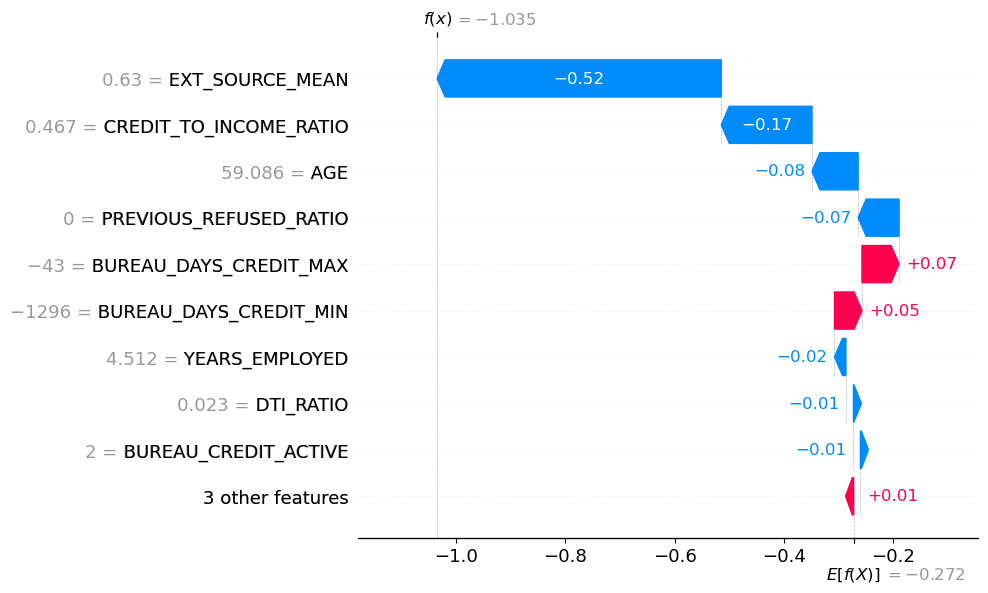

In [98]:
for i in [0,100]:
    shap.waterfall_plot(shap.Explanation(
        values=explainer.shap_values(X_validation.iloc[i]),
        base_values=explainer.expected_value,
        data=X_validation.iloc[i],
        feature_names=X_validation.columns))

#### Saving a Logistic Rregression model

In [123]:
import joblib

In [124]:
joblib.dump(xgb,'XGB_Base_Model.pkl')

['XGB_Base_Model.pkl']

In [125]:
joblib.dump(calibrated_xgb,'XGB_Calibrated_Model.pkl')

['XGB_Calibrated_Model.pkl']

In [126]:
joblib.dump(features,'feature_names.pkl')

['feature_names.pkl']

In [127]:
X_test=Test_data[features]

In [128]:
probablity=xgb.predict_proba(X_test)[:,1]

In [129]:
predictions=(probablity>treshold).astype(int)

In [130]:
predictions

array([1, 1, 0, ..., 1, 1, 1], shape=(48744,))